In [1]:
using LinearAlgebra
using Printf

function solve_hf_state_vector(t_L::Float64, t_S::Float64, U::Float64, mu::Float64; max_iter=1000, tol=1e-8)
    N_sites = 4
    
    # 1. ホッピング行列 T の構築
    # ※ Juliaは配列のインデックスが1から始まります（1-based indexing）
    T = zeros(Float64, N_sites, N_sites)
    edges_L = [(1, 2), (3, 4), (4, 1)] 
    edges_S = [(2, 3)]
    
    for (i, j) in edges_L
        T[i, j] = T[j, i] = -t_L
    end
    for (i, j) in edges_S
        T[i, j] = T[j, i] = -t_S
    end
    
    # 2. 反強磁性的な初期状態
    n_up = [0.8, 0.2, 0.8, 0.2]
    n_dn = [0.2, 0.8, 0.2, 0.8]
    
    eigvec_up = zeros(Float64, N_sites, N_sites)
    eigvec_dn = zeros(Float64, N_sites, N_sites)
    
    # 自己無撞着ループ
    for iteration in 1:max_iter
        # 平均場ハミルトニアン
        # Juliaの I は単位行列を表し、サイズを自動的に合わせてくれます
        H_up = T + diagm(U .* n_dn) - mu * I
        H_dn = T + diagm(U .* n_up) - mu * I
        
        # 対角化
        F_up = eigen(H_up)
        F_dn = eigen(H_dn)
        
        eigvec_up = F_up.vectors
        eigvec_dn = F_dn.vectors
        
        # ハーフフィリング（各スピン下から2軌道を占有）
        new_n_up = eigvec_up[:, 1].^2 .+ eigvec_up[:, 2].^2
        new_n_dn = eigvec_dn[:, 1].^2 .+ eigvec_dn[:, 2].^2
            
        diff = maximum(abs.(new_n_up .- n_up)) + maximum(abs.(new_n_dn .- n_dn))
        if diff < tol
            break
        end
        
        alpha = 0.5
        n_up = alpha .* new_n_up .+ (1.0 - alpha) .* n_up
        n_dn = alpha .* new_n_dn .+ (1.0 - alpha) .* n_dn
    end

    # 3. 256次元Fock空間における状態ベクトルの構築
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]
    
    # 可変長引数を用いたクロネッカー積（Pythonのmake_matrixに相当）
    function make_matrix(ops...)
        r = ones(1, 1)
        for op in reverse(ops)
            r = kron(op, r)
        end
        return r
    end
    
    # 生成演算子の辞書
    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    
    # HF軌道の生成演算子を作成
    Ddag_up_1 = sum(eigvec_up[i, 1] * Cdag["$(i)u"] for i in 1:4)
    Ddag_up_2 = sum(eigvec_up[i, 2] * Cdag["$(i)u"] for i in 1:4)
    Ddag_dn_1 = sum(eigvec_dn[i, 1] * Cdag["$(i)d"] for i in 1:4)
    Ddag_dn_2 = sum(eigvec_dn[i, 2] * Cdag["$(i)d"] for i in 1:4)
    
    # 真空状態（256次元）
    vac = zeros(Float64, 256)
    vac[1] = 1.0  # Juliaではインデックス1が状態 [0,0,0,0,0,0,0,0] に対応
    
    # スレイター行列式の構築
    # ※括弧をつけることで、行列×行列ではなく、常に行列×ベクトルの計算順序になり高速化されます
    hf_state = Ddag_up_1 * (Ddag_up_2 * (Ddag_dn_1 * (Ddag_dn_2 * vac)))
    
    # 規格化
    hf_state = hf_state / norm(hf_state)
    
    return hf_state
end

function main()
    t_L = 1.0
    t_S = 1.0
    U = 0.2
    mu = U / 2.0

    # HF状態ベクトルの取得
    hf_vec = solve_hf_state_vector(t_L, t_S, U, mu)

    println("Hartree-Fock Ground State Vector (256-dim):")
    threshold = 0.1
    println(" Index | Amplitude | State |4d,4u, 3d,3u, 2d,2u, 1d,1u⟩")
    println("-" ^ 60)
    
    # 振幅が大きい成分だけをフィルタリングして表示
    for i in 1:256
        amp = hf_vec[i]
        if abs(amp) > threshold
            # 物理的状態としてのインデックス（0始まり）
            idx = i - 1 
            # UInt8に変換して8ビットの2進数文字列を取得
            bin_str = bitstring(UInt8(idx))
            @printf("  %3d  |  %8.4f | |%s⟩\n", idx, amp, bin_str)
        end
    end
end

main()

Hartree-Fock Ground State Vector (256-dim):
 Index | Amplitude | State |4d,4u, 3d,3u, 2d,2u, 1d,1u⟩
------------------------------------------------------------
   15  |   -0.1218 | |00001111⟩
   27  |    0.2499 | |00011011⟩
   30  |   -0.1218 | |00011110⟩
   45  |   -0.1218 | |00101101⟩
   57  |    0.2499 | |00111001⟩
   60  |    0.1218 | |00111100⟩
   75  |    0.1218 | |01001011⟩
   90  |   -0.1218 | |01011010⟩
  105  |   -0.1218 | |01101001⟩
  120  |   -0.1218 | |01111000⟩
  135  |    0.1218 | |10000111⟩
  141  |   -0.2499 | |10001101⟩
  147  |    0.2499 | |10010011⟩
  150  |   -0.1218 | |10010110⟩
  153  |    0.5128 | |10011001⟩
  156  |    0.2499 | |10011100⟩
  165  |   -0.1218 | |10100101⟩
  177  |   -0.2499 | |10110001⟩
  180  |   -0.1218 | |10110100⟩
  195  |    0.1218 | |11000011⟩
  201  |    0.2499 | |11001001⟩
  210  |    0.1218 | |11010010⟩
  216  |    0.2499 | |11011000⟩
  225  |    0.1218 | |11100001⟩
  240  |   -0.1218 | |11110000⟩


In [14]:
using LinearAlgebra
using Printf

# ==========================================
# 共通の演算子構築用関数
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]

    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    
    return Cdag
end

# ==========================================
# 1. 厳密対角化 (Exact Diagonalization)
# ==========================================
function solve_ed_state_vector(t_L::Float64, t_S::Float64, U::Float64, mu::Float64)
    Cdag = get_creation_ops()
    
    C_op = Dict{String, Matrix{Float64}}()
    N_op = Dict{String, Matrix{Float64}}()
    
    for (key, op) in Cdag
        C_op[key] = op'  # Juliaでは `'` でエルミート共役をとれます
        N_op[key] = op * C_op[key]
    end

    hamil = zeros(Float64, 256, 256)
    
    # t_L
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L
        hamil .+= -t_L .* (Cdag[k1] * C_op[k2])
    end

    # t_S
    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S
        hamil .+= -t_S .* (Cdag[k1] * C_op[k2])
    end

    # U
    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U
        hamil .+= U .* (N_op[k1] * N_op[k2])
    end

    # mu
    for op in values(N_op)
        hamil .+= -mu .* op
    end

    # 対称行列であることを明示して対角化（高速化と数値誤差の抑制）
    F = eigen(Symmetric(hamil))
        println("Exact Diagonalization Eigenvalues:")
        for (i, val) in enumerate(F.values)
             @printf("  %3d: %8.4f\n", i, val)
        end
        println("-" ^ 40)
    
    # 基底状態（最もエネルギーの低い状態）の固有ベクトルを返す
    return F.vectors[:, 1]

end

# ==========================================
# 2. ハートリーフォック近似 (Hartree-Fock)
# ==========================================
function solve_hf_state_vector(t_L::Float64, t_S::Float64, U::Float64, mu::Float64; max_iter=1000, tol=1e-8)
    N_sites = 4
    
    T = zeros(Float64, N_sites, N_sites)
    for (i, j) in [(1, 2), (3, 4), (4, 1)] 
        T[i, j] = T[j, i] = -t_L
    end
    for (i, j) in [(2, 3)]
        T[i, j] = T[j, i] = -t_S
    end
    
    n_up = [0.8, 0.2, 0.8, 0.2]
    n_dn = [0.2, 0.8, 0.2, 0.8]
    
    eigvec_up = zeros(Float64, N_sites, N_sites)
    eigvec_dn = zeros(Float64, N_sites, N_sites)

    eigval_up = zeros(Float64, N_sites)
    eigval_dn = zeros(Float64, N_sites)
    
    for iteration in 1:max_iter
        H_up = T + diagm(U .* n_dn) - mu * I
        H_dn = T + diagm(U .* n_up) - mu * I
        
        F_up = eigen(Symmetric(H_up))
        F_dn = eigen(Symmetric(H_dn))
        
        eigvec_up = F_up.vectors
        eigvec_dn = F_dn.vectors

        eigval_up = F_up.values
        eigval_dn = F_dn.values
        
        new_n_up = eigvec_up[:, 1].^2 .+ eigvec_up[:, 2].^2
        new_n_dn = eigvec_dn[:, 1].^2 .+ eigvec_dn[:, 2].^2
            
        diff = maximum(abs.(new_n_up .- n_up)) + maximum(abs.(new_n_dn .- n_dn))
        if diff < tol
            break
        end
        
        alpha = 0.5
        n_up = alpha .* new_n_up .+ (1.0 - alpha) .* n_up
        n_dn = alpha .* new_n_dn .+ (1.0 - alpha) .* n_dn
    end


    Cdag = get_creation_ops()
    
    Ddag_up_1 = sum(eigvec_up[i, 1] * Cdag["$(i)u"] for i in 1:4)
    Ddag_up_2 = sum(eigvec_up[i, 2] * Cdag["$(i)u"] for i in 1:4)
    Ddag_dn_1 = sum(eigvec_dn[i, 1] * Cdag["$(i)d"] for i in 1:4)
    Ddag_dn_2 = sum(eigvec_dn[i, 2] * Cdag["$(i)d"] for i in 1:4)
    
    vac = zeros(Float64, 256)
    vac[1] = 1.0 
    
    hf_state = Ddag_up_1 * (Ddag_up_2 * (Ddag_dn_1 * (Ddag_dn_2 * vac)))
    hf_state = hf_state / norm(hf_state)

    println("Hartree-Fock Eigenvalues (Diagonalized Fock Matrix):")
    for (i, val) in enumerate(vcat(eigval_up, eigval_dn))
        @printf("  %3d: %8.4f\n", i, val)
    end 

    
    return hf_state
end

# ==========================================
# 3. 比較実行
# ==========================================
function main()
    t_L = 1.0
    t_S = 1.0
    
    U_list = [0.2]
    
    println(@sprintf("%5s | %30s", "U", "Fidelity (|⟨Ψ_ED | Ψ_HF⟩|²)"))
    println("-" ^ 40)
    
    for U in U_list
        mu = U / 2.0
        
        vec_ed = solve_ed_state_vector(t_L, t_S, U, mu)
        vec_hf = solve_hf_state_vector(t_L, t_S, U, mu)
        
        # 内積の計算とFidelity
        inner_prod = dot(vec_ed, vec_hf)
        fidelity = abs(inner_prod)^2
        
        println(@sprintf("%5.1f | %30.6f", U, fidelity))
    end
end

main()

    U |    Fidelity (|⟨Ψ_ED | Ψ_HF⟩|²)
----------------------------------------
Exact Diagonalization Eigenvalues:
    1:  -4.2540
    2:  -4.2516
    3:  -4.2516
    4:  -4.2516
    5:  -4.2022
    6:  -4.2022
    7:  -4.2022
    8:  -4.2022
    9:  -4.2022
   10:  -4.2022
   11:  -4.2022
   12:  -4.2022
   13:  -4.1542
   14:  -4.1515
   15:  -4.1515
   16:  -4.1515
   17:  -2.3025
   18:  -2.3025
   19:  -2.3025
   20:  -2.3025
   21:  -2.3025
   22:  -2.3025
   23:  -2.3000
   24:  -2.3000
   25:  -2.3000
   26:  -2.3000
   27:  -2.3000
   28:  -2.3000
   29:  -2.3000
   30:  -2.3000
   31:  -2.2518
   32:  -2.2518
   33:  -2.2518
   34:  -2.2518
   35:  -2.2518
   36:  -2.2518
   37:  -2.2518
   38:  -2.2518
   39:  -2.2000
   40:  -2.2000
   41:  -2.2000
   42:  -2.2000
   43:  -2.2000
   44:  -2.2000
   45:  -2.2000
   46:  -2.2000
   47:  -2.2000
   48:  -2.2000
   49:  -2.2000
   50:  -2.2000
   51:  -2.2000
   52:  -2.2000
   53:  -2.2000
   54:  -2.2000
   55:  -2.2000
   56

In [3]:
function make_h(μ,n,V)
    ham = zeros(Float64,n,n)
    t =1
    for i=1:n
        j = i+1
        j += ifelse(j > n,-n,0)
        ham[i,j] = -t
        
        j = i-1
        j += ifelse(j < 1,n,0)
        ham[i,j] = -t
        
        j = i
        ham[i,j] = -μ+ V[i]
        
    end
    return ham
end

make_h (generic function with 1 method)

In [4]:
using Random
using LinearAlgebra
Random.seed!(123)

function solve_v(U,N)
    μ = 0
    Vup = rand(N)
    Vdown = rand(N)
    Vupold = copy(Vup)
    Vdownold = copy(Vdown)
    
    itemax = 2000
    ene = 0
    eps = 1e-12
    r = 0.05
    
    for ite=1:itemax
        hamup = make_h(μ,N,Vup)
        hamdown= make_h(μ,N,Vdown)
        eup,uup = eigen(hamup)
        edown,udown = eigen(hamdown)
        t = 1

        for i=1:N
            Vup[i] = 0
            Vdown[i] = 0
            for n=1:div(N,2)
                Vup[i] += U*abs(udown[i,n])^2
                Vdown[i] += U*abs(uup[i,n])^2
            end
        end

        Vup = Vup*r + Vupold*(1-r)
        Vdown = Vdown*r + Vdownold*(1-r)
        
        errup = sum(abs.(Vup - Vupold))/sum(abs.(Vupold))
        errdown = sum(abs.(Vdown - Vdownold))/sum(abs.(Vdownold))
        
        ene = sum(eup[1:div(N,2)])+sum(edown[1:div(N,2)]) - sum(Vup.*Vdown)/U

        if errup < eps && errdown < eps

            println(Vup./U)
            println(Vdown./U)
            println(errup,"\t",ite," ene = ",ene)
            return Vupold,Vdownold,ene
        end
        
        Vupold = copy(Vup)
        Vdownold = copy(Vdown)
        
        
    end

    println("not converged")
    return Vupold,Vdownold,ene
    
    
end

solve_v (generic function with 1 method)

[0.991271791978522, 0.008728208017498169, 0.9912717919791738, 0.008728208016789581]
[0.9912717919785344, 0.008728208017522967, 0.9912717919791862, 0.008728208016813776]
9.723879109361923e-13	513 ene = -30.528594089447047
-30.528594089447047
[0.9891482510997789, 0.010851748894899298, 0.9891482510995505, 0.010851748894748983]
[0.9891482510999154, 0.010851748894990352, 0.9891482510996632, 0.010851748894901057]
9.70249098934396e-13	507 ene = -27.431568443330736
-27.431568443330736
[0.01384435790485233, 0.9861556420910663, 0.013844357904207929, 0.9861556420921016]
[0.013844357904850724, 0.9861556420910548, 0.013844357904184664, 0.9861556420921015]
9.552595751492506e-13	514 ene = -24.350139311513093
-24.350139311513093
[0.9817576707309768, 0.01824232926630601, 0.9817576707319844, 0.01824232926711647]
[0.9817576707309548, 0.018242329266278418, 0.9817576707319595, 0.018242329267096465]
9.76710521579441e-13	528 ene = -21.291023701802157
-21.291023701802157
[0.9749489220259556, 0.02505107797278,

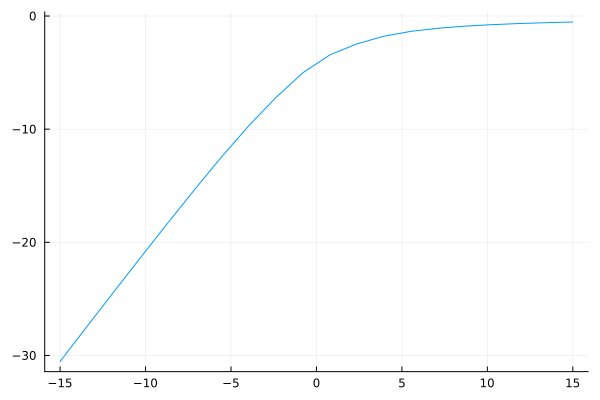

In [5]:
nsite = 4

nU = 20
Us = range(-15,length=nU,stop=15)
μs = Us *0
es = zeros(Float64,nU)
for i=1:nU
    vup,vdown,ene = solve_v(Us[i],nsite)
    println(ene)
    es[i] = ene
    #println(Us[i],"\t",es[i])
end
using Plots
fig = plot(Us,es,labels="")
savefig(fig,"Fig.png")
fig

In [15]:
using LinearAlgebra
using Printf

# ==========================================
# 共通の演算子構築用関数
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]

    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    
    return Cdag
end

# ==========================================
# 1. 厳密対角化 (Exact Diagonalization)
# ==========================================
function solve_ed_state_vector(t_L::Float64, t_S::Float64, U::Float64, mu::Float64)
    Cdag = get_creation_ops()
    
    C_op = Dict{String, Matrix{Float64}}()
    N_op = Dict{String, Matrix{Float64}}()
    
    for (key, op) in Cdag
        C_op[key] = op'  # Juliaでは `'` でエルミート共役をとれます
        N_op[key] = op * C_op[key]
    end

    hamil = zeros(Float64, 256, 256)
    
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L
        hamil .+= -t_L .* (Cdag[k1] * C_op[k2])
    end

    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S
        hamil .+= -t_S .* (Cdag[k1] * C_op[k2])
    end

    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U
        hamil .+= U .* (N_op[k1] * N_op[k2])
    end

    for op in values(N_op)
        hamil .+= -mu .* op
    end

    F = eigen(Symmetric(hamil))
    println("Exact Diagonalization Eigenvalues (Top 5):")
    for (i, val) in enumerate(F.values[1:5])
         @printf("  %3d: %8.4f\n", i, val)
    end
    println("-" ^ 40)
    
    # 固有ベクトルと、基底状態のエネルギー(固有値の最小値)をタプルで返す
    return F.vectors[:, 1], F.values[1]
end

# ==========================================
# 2. ハートリーフォック近似 (Hartree-Fock)
# ==========================================
function solve_hf_state_vector(t_L::Float64, t_S::Float64, U::Float64, mu::Float64; max_iter=1000, tol=1e-8)
    N_sites = 4
    
    T = zeros(Float64, N_sites, N_sites)
    for (i, j) in [(1, 2), (3, 4), (4, 1)] 
        T[i, j] = T[j, i] = -t_L
    end
    for (i, j) in [(2, 3)]
        T[i, j] = T[j, i] = -t_S
    end
    
    n_up = [0.8, 0.2, 0.8, 0.2]
    n_dn = [0.2, 0.8, 0.2, 0.8]
    
    eigvec_up = zeros(Float64, N_sites, N_sites)
    eigvec_dn = zeros(Float64, N_sites, N_sites)

    eigval_up = zeros(Float64, N_sites)
    eigval_dn = zeros(Float64, N_sites)
    
    for iteration in 1:max_iter
        H_up = T + diagm(U .* n_dn) - mu * I
        H_dn = T + diagm(U .* n_up) - mu * I
        
        F_up = eigen(Symmetric(H_up))
        F_dn = eigen(Symmetric(H_dn))
        
        eigvec_up = F_up.vectors
        eigvec_dn = F_dn.vectors

        eigval_up = F_up.values
        eigval_dn = F_dn.values
        
        new_n_up = eigvec_up[:, 1].^2 .+ eigvec_up[:, 2].^2
        new_n_dn = eigvec_dn[:, 1].^2 .+ eigvec_dn[:, 2].^2
            
        diff = maximum(abs.(new_n_up .- n_up)) + maximum(abs.(new_n_dn .- n_dn))
        if diff < tol
            break
        end
        
        alpha = 0.5
        n_up = alpha .* new_n_up .+ (1.0 - alpha) .* n_up
        n_dn = alpha .* new_n_dn .+ (1.0 - alpha) .* n_dn
    end

    Cdag = get_creation_ops()
    
    Ddag_up_1 = sum(eigvec_up[i, 1] * Cdag["$(i)u"] for i in 1:4)
    Ddag_up_2 = sum(eigvec_up[i, 2] * Cdag["$(i)u"] for i in 1:4)
    Ddag_dn_1 = sum(eigvec_dn[i, 1] * Cdag["$(i)d"] for i in 1:4)
    Ddag_dn_2 = sum(eigvec_dn[i, 2] * Cdag["$(i)d"] for i in 1:4)
    
    vac = zeros(Float64, 256)
    vac[1] = 1.0 
    
    hf_state = Ddag_up_1 * (Ddag_up_2 * (Ddag_dn_1 * (Ddag_dn_2 * vac)))
    hf_state = hf_state / norm(hf_state)

    # ===== 追加: HFトータルエネルギーの計算 =====
    # 占有軌道(下から2つ)のエネルギー和 - 二重カウント分
    E_HF = eigval_up[1] + eigval_up[2] + eigval_dn[1] + eigval_dn[2] - U * sum(n_up .* n_dn)

    println("Hartree-Fock Eigenvalues (Diagonalized Fock Matrix):")
    for (i, val) in enumerate(vcat(eigval_up, eigval_dn))
        @printf("  %3d: %8.4f\n", i, val)
    end 
    @printf("\n-> Hartree-Fock Total Energy: %.6f\n", E_HF)
    println("-" ^ 40)
    
    # ベクトルとエネルギーを返す
    return hf_state, E_HF
end

# ==========================================
# 3. 比較実行
# ==========================================
function main()
    t_L = 1.0
    t_S = 1.0
    
    # 少し U を変えて比較してみます
    U_list = [0.2, 4.0]
    
    println(@sprintf("%5s | %12s | %15s | %15s", "U", "Fidelity", "E_ED (Exact)", "E_HF (Approx)"))
    println("-" ^ 55)
    
    for U in U_list
        mu = U / 2.0
        
        # 戻り値でベクトルとエネルギーの両方を受け取る
        vec_ed, E_ED = solve_ed_state_vector(t_L, t_S, U, mu)
        vec_hf, E_HF = solve_hf_state_vector(t_L, t_S, U, mu)
        
        # 内積の計算とFidelity
        inner_prod = dot(vec_ed, vec_hf)
        fidelity = abs(inner_prod)^2
        
        println(@sprintf("%5.1f | %12.6f | %15.6f | %15.6f", U, fidelity, E_ED, E_HF))
    end
end

main()

    U |     Fidelity |    E_ED (Exact) |   E_HF (Approx)
-------------------------------------------------------
Exact Diagonalization Eigenvalues (Top 5):
    1:  -4.2540
    2:  -4.2516
    3:  -4.2516
    4:  -4.2516
    5:  -4.2022
----------------------------------------
Hartree-Fock Eigenvalues (Diagonalized Fock Matrix):
    1:  -2.0007
    2:  -0.0513
    3:   0.0513
    4:   2.0007
    5:  -2.0007
    6:  -0.0513
    7:   0.0513
    8:   2.0007

-> Hartree-Fock Total Energy: -4.251282
----------------------------------------
  0.2 |     0.499685 |       -4.253970 |       -4.251282
Exact Diagonalization Eigenvalues (Top 5):
    1: -10.1027
    2:  -9.8064
    3:  -9.8064
    4:  -9.8064
    5:  -9.0681
----------------------------------------
Hartree-Fock Eigenvalues (Diagonalized Fock Matrix):
    1:  -2.5815
    2:  -1.6323
    3:   1.6323
    4:   2.5815
    5:  -2.5815
    6:  -1.6323
    7:   1.6323
    8:   2.5815

-> Hartree-Fock Total Energy: -9.763298
-----------------

In [17]:
using LinearAlgebra
using Printf

# ==========================================
# 共通の演算子構築用関数
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]

    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    
    return Cdag
end

# ==========================================
# 1. 厳密対角化 (Exact Diagonalization)
# ==========================================
function solve_ed_state_vector(t_L::Float64, t_S::Float64, U::Float64, mu::Float64)
    Cdag = get_creation_ops()
    
    C_op = Dict{String, Matrix{Float64}}()
    N_op = Dict{String, Matrix{Float64}}()
    
    for (key, op) in Cdag
        C_op[key] = op'  # Juliaでは `'` でエルミート共役をとれます
        N_op[key] = op * C_op[key]
    end

    hamil = zeros(Float64, 256, 256)
    
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L
        hamil .+= -t_L .* (Cdag[k1] * C_op[k2])
    end

    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S
        hamil .+= -t_S .* (Cdag[k1] * C_op[k2])
    end

    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U
        hamil .+= U .* (N_op[k1] * N_op[k2])
    end

    for op in values(N_op)
        hamil .+= -mu .* op
    end

    F = eigen(Symmetric(hamil))
    println("Exact Diagonalization Eigenvalues (Top 5):")
    for (i, val) in enumerate(F.values[1:5])
         @printf("  %3d: %8.4f\n", i, val)
    end
    println("-" ^ 40)
    
    # 固有ベクトルと、基底状態のエネルギー(固有値の最小値)をタプルで返す
    return F.vectors[:, 1], F.values[1]
end

# ==========================================
# 2. ハートリーフォック近似 (Hartree-Fock)
# ==========================================
function solve_hf_state_vector(t_L::Float64, t_S::Float64, U::Float64, mu::Float64; max_iter=1000, tol=1e-8)
    N_sites = 4
    
    T = zeros(Float64, N_sites, N_sites)
    for (i, j) in [(1, 2), (3, 4), (4, 1)] 
        T[i, j] = T[j, i] = -t_L
    end
    for (i, j) in [(2, 3)]
        T[i, j] = T[j, i] = -t_S
    end
    
    n_up = [0.8, 0.2, 0.8, 0.2]
    n_dn = [0.2, 0.8, 0.2, 0.8]
    
    eigvec_up = zeros(Float64, N_sites, N_sites)
    eigvec_dn = zeros(Float64, N_sites, N_sites)

    eigval_up = zeros(Float64, N_sites)
    eigval_dn = zeros(Float64, N_sites)
    
    # ===== 追加: ループを抜けた後も回数を保持するための変数 =====
    final_iter = max_iter 
    
    for iteration in 1:max_iter
        H_up = T + diagm(U .* n_dn) - mu * I
        H_dn = T + diagm(U .* n_up) - mu * I
        
        F_up = eigen(Symmetric(H_up))
        F_dn = eigen(Symmetric(H_dn))
        
        eigvec_up = F_up.vectors
        eigvec_dn = F_dn.vectors

        eigval_up = F_up.values
        eigval_dn = F_dn.values
        
        new_n_up = eigvec_up[:, 1].^2 .+ eigvec_up[:, 2].^2
        new_n_dn = eigvec_dn[:, 1].^2 .+ eigvec_dn[:, 2].^2
            
        diff = maximum(abs.(new_n_up .- n_up)) + maximum(abs.(new_n_dn .- n_dn))
        
        if diff < tol
            final_iter = iteration # 収束した時点のイテレーション回数を記録
            break
        end
        
        alpha = 0.5
        n_up = alpha .* new_n_up .+ (1.0 - alpha) .* n_up
        n_dn = alpha .* new_n_dn .+ (1.0 - alpha) .* n_dn
    end

    Cdag = get_creation_ops()
    
    Ddag_up_1 = sum(eigvec_up[i, 1] * Cdag["$(i)u"] for i in 1:4)
    Ddag_up_2 = sum(eigvec_up[i, 2] * Cdag["$(i)u"] for i in 1:4)
    Ddag_dn_1 = sum(eigvec_dn[i, 1] * Cdag["$(i)d"] for i in 1:4)
    Ddag_dn_2 = sum(eigvec_dn[i, 2] * Cdag["$(i)d"] for i in 1:4)
    
    vac = zeros(Float64, 256)
    vac[1] = 1.0 
    
    hf_state = Ddag_up_1 * (Ddag_up_2 * (Ddag_dn_1 * (Ddag_dn_2 * vac)))
    hf_state = hf_state / norm(hf_state)

    # ===== HFトータルエネルギーの計算 =====
    # 占有軌道(下から2つ)のエネルギー和 - 二重カウント分
    E_HF = eigval_up[1] + eigval_up[2] + eigval_dn[1] + eigval_dn[2] - U * sum(n_up .* n_dn)

    println("Hartree-Fock Eigenvalues (Diagonalized Fock Matrix):")
    for (i, val) in enumerate(vcat(eigval_up, eigval_dn))
        @printf("  %3d: %8.4f\n", i, val)
    end 
    
    # 収束にかかったイテレーション回数も併せて出力
    @printf("\n-> Hartree-Fock Total Energy: %.6f (Converged in %d iterations)\n", E_HF, final_iter)
    println("-" ^ 40)
    
    # ベクトル、エネルギーに加えて、イテレーション回数も返す
    return hf_state, E_HF, final_iter
end

# ==========================================
# 3. 比較実行
# ==========================================
function main()
    t_L = 1.0
    t_S = 1.0
    
    U_list = [0, 0.2, 0.4, 0.8, 4.0]
    
    # イテレーション回数の列 (Iterations) を追加
    println(@sprintf("%5s | %12s | %15s | %15s | %10s", "U", "Fidelity", "E_ED (Exact)", "E_HF (Approx)", "Iterations"))
    println("-" ^ 68)
    
    for U in U_list
        mu = U / 2.0
        
        vec_ed, E_ED = solve_ed_state_vector(t_L, t_S, U, mu)
        # イテレーション回数も受け取る
        vec_hf, E_HF, iter_count = solve_hf_state_vector(t_L, t_S, U, mu)
        
        # 内積の計算とFidelity
        inner_prod = dot(vec_ed, vec_hf)
        fidelity = abs(inner_prod)^2
        
        println(@sprintf("%5.1f | %12.6f | %15.6f | %15.6f | %10d", U, fidelity, E_ED, E_HF, iter_count))
    end
end

main()

    U |     Fidelity |    E_ED (Exact) |   E_HF (Approx) | Iterations
--------------------------------------------------------------------
Exact Diagonalization Eigenvalues (Top 5):
    1:  -4.0000
    2:  -4.0000
    3:  -4.0000
    4:  -4.0000
    5:  -4.0000
----------------------------------------
Hartree-Fock Eigenvalues (Diagonalized Fock Matrix):
    1:  -2.0000
    2:   0.0000
    3:   0.0000
    4:   2.0000
    5:  -2.0000
    6:   0.0000
    7:   0.0000
    8:   2.0000

-> Hartree-Fock Total Energy: -4.000000 (Converged in 27 iterations)
----------------------------------------
  0.0 |     0.015403 |       -4.000000 |       -4.000000 |         27
Exact Diagonalization Eigenvalues (Top 5):
    1:  -4.2540
    2:  -4.2516
    3:  -4.2516
    4:  -4.2516
    5:  -4.2022
----------------------------------------
Hartree-Fock Eigenvalues (Diagonalized Fock Matrix):
    1:  -2.0007
    2:  -0.0513
    3:   0.0513
    4:   2.0007
    5:  -2.0007
    6:  -0.0513
    7:   0.0513
    8:

In [19]:
using LinearAlgebra
using Printf

# ==========================================
# 共通の演算子構築用関数
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]

    Cdag = Dict{String, Matrix{Float64}}()
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    
    return Cdag
end

# ハミルトニアンの構築
function build_hamiltonian(t_L::Float64, t_S::Float64, U::Float64, mu::Float64)
    Cdag = get_creation_ops()
    C_op = Dict{String, Matrix{Float64}}()
    N_op = Dict{String, Matrix{Float64}}()
    for (key, op) in Cdag
        C_op[key] = op'
        N_op[key] = op * C_op[key]
    end

    hamil = zeros(Float64, 256, 256)
    
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end

    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end

    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end

    for op in values(N_op); hamil .+= -mu .* op; end
    
    return hamil
end

# 1. 厳密対角化 (ED)
function solve_ed_state_vector(hamil::Matrix{Float64})
    F = eigen(Symmetric(hamil))
    return F.vectors[:, 1], F.values[1]
end

# 2. Hartree-Fock近似で軌道を求める
function solve_hf_orbitals(t_L::Float64, t_S::Float64, U::Float64, mu::Float64; max_iter=1000, tol=1e-8)
    N_sites = 4
    T = zeros(Float64, N_sites, N_sites)
    for (i, j) in [(1, 2), (3, 4), (4, 1)]; T[i, j] = T[j, i] = -t_L; end
    for (i, j) in [(2, 3)]; T[i, j] = T[j, i] = -t_S; end
    
    n_up = [0.8, 0.2, 0.8, 0.2]
    n_dn = [0.2, 0.8, 0.2, 0.8]
    
    eigvec_up = zeros(Float64, N_sites, N_sites)
    eigvec_dn = zeros(Float64, N_sites, N_sites)
    eigval_up = zeros(Float64, N_sites)
    eigval_dn = zeros(Float64, N_sites)
    
    for iteration in 1:max_iter
        H_up = T + diagm(U .* n_dn) - mu * I
        H_dn = T + diagm(U .* n_up) - mu * I
        
        F_up = eigen(Symmetric(H_up))
        F_dn = eigen(Symmetric(H_dn))
        
        eigvec_up = F_up.vectors
        eigvec_dn = F_dn.vectors
        eigval_up = F_up.values
        eigval_dn = F_dn.values
        
        new_n_up = eigvec_up[:, 1].^2 .+ eigvec_up[:, 2].^2
        new_n_dn = eigvec_dn[:, 1].^2 .+ eigvec_dn[:, 2].^2
            
        diff = maximum(abs.(new_n_up .- n_up)) + maximum(abs.(new_n_dn .- n_dn))
        if diff < tol; break; end
        
        alpha = 0.5
        n_up = alpha .* new_n_up .+ (1.0 - alpha) .* n_up
        n_dn = alpha .* new_n_dn .+ (1.0 - alpha) .* n_dn
    end
    
    E_HF = eigval_up[1] + eigval_up[2] + eigval_dn[1] + eigval_dn[2] - U * sum(n_up .* n_dn)
    return eigvec_up, eigvec_dn, E_HF
end

# 任意のスレイター行列式(256次元ベクトル)を作成する関数
function build_slater_determinant(up_idx, dn_idx, Ddag_up, Ddag_dn)
    vac = zeros(Float64, 256)
    vac[1] = 1.0
    res = vac
    for i in reverse(dn_idx); res = Ddag_dn[i] * res; end
    for i in reverse(up_idx); res = Ddag_up[i] * res; end
    return res / norm(res)
end

# 3. CID (Configuration Interaction with Doubles) の実行
function solve_cid_state_vector(hamil::Matrix{Float64}, eigvec_up::Matrix{Float64}, eigvec_dn::Matrix{Float64})
    Cdag = get_creation_ops()
    Ddag_up = [sum(eigvec_up[s, k] * Cdag["$(s)u"] for s in 1:4) for k in 1:4]
    Ddag_dn = [sum(eigvec_dn[s, k] * Cdag["$(s)d"] for s in 1:4) for k in 1:4]
    
    # HF基底状態 (軌道 1, 2 が占有)
    hf_state = build_slater_determinant([1, 2], [1, 2], Ddag_up, Ddag_dn)
    
    # CID基底のリスト（最初はHF基底）
    basis_vectors = [hf_state]
    
    # ==== Doubles (2励起配置) を18個生成する ====
    # 占有軌道={1, 2}, 空軌道={3, 4}
    
    # 1. アップスピンが2個とも励起
    push!(basis_vectors, build_slater_determinant([3, 4], [1, 2], Ddag_up, Ddag_dn))
    
    # 2. ダウンスピンが2個とも励起
    push!(basis_vectors, build_slater_determinant([1, 2], [3, 4], Ddag_up, Ddag_dn))
    
    # 3. アップから1個、ダウンから1個励起 (4×4 = 16通り)
    up_1ex = [[2, 3], [2, 4], [1, 3], [1, 4]]
    dn_1ex = [[2, 3], [2, 4], [1, 3], [1, 4]]
    for u_idx in up_1ex
        for d_idx in dn_1ex
            push!(basis_vectors, build_slater_determinant(u_idx, d_idx, Ddag_up, Ddag_dn))
        end
    end
    
    # 19個の基底ベクトルを並べて行列 V (256行 × 19列) を作る
    V = hcat(basis_vectors...)
    
    # CID部分空間 (19x19) にハミルトニアンを投影して対角化
    H_CID = V' * hamil * V
    F = eigen(Symmetric(H_CID))
    
    # 最低エネルギーの固有ベクトル (長さ19)
    c = F.vectors[:, 1]
    E_CID = F.values[1]
    
    # 256次元ベクトルに戻す
    cid_state = V * c
    
    return hf_state, cid_state, E_CID
end

# ==========================================
# 4. メイン実行部
# ==========================================
function main()
    t_L = 1.0
    t_S = 1.0
    U_list = [0, 0.2, 2.0, 4.0, 8.0]
    
    println(@sprintf("%5s | %10s | %10s | %12s | %12s | %12s", "U", "Fid (HF)", "Fid (CID)", "E_HF", "E_CID", "E_ED(Exact)"))
    println("-" ^ 75)
    
    for U in U_list
        mu = U / 2.0
        
        hamil = build_hamiltonian(t_L, t_S, U, mu)
        vec_ed, E_ED = solve_ed_state_vector(hamil)
        
        eigvec_up, eigvec_dn, E_HF = solve_hf_orbitals(t_L, t_S, U, mu)
        vec_hf, vec_cid, E_CID = solve_cid_state_vector(hamil, eigvec_up, eigvec_dn)
        
        fid_hf = abs(dot(vec_ed, vec_hf))^2
        fid_cid = abs(dot(vec_ed, vec_cid))^2
        
        println(@sprintf("%5.1f | %10.6f | %10.6f | %12.6f | %12.6f | %12.6f", 
                         U, fid_hf, fid_cid, E_HF, E_CID, E_ED))
    end
end

main()

    U |   Fid (HF) |  Fid (CID) |         E_HF |        E_CID |  E_ED(Exact)
---------------------------------------------------------------------------
  0.0 |   0.015403 |   0.000464 |    -4.000000 |    -4.000000 |    -4.000000
  0.2 |   0.499685 |   0.711127 |    -4.251282 |    -4.253056 |    -4.253970
  2.0 |   0.477287 |   0.677800 |    -6.661001 |    -6.768169 |    -6.828427
  4.0 |   0.429246 |   0.616118 |    -9.763298 |    -9.939190 |   -10.102748
  8.0 |   0.369593 |   0.551089 |   -16.968871 |   -17.101845 |   -17.320235


In [21]:
using LinearAlgebra
using Printf

# ==========================================
# 共通の演算子構築用関数
# ==========================================
function make_matrix(ops...)
    r = ones(1, 1)
    for op in reverse(ops)
        r = kron(op, r)
    end
    return r
end

function get_creation_ops()
    cdag = [0.0 0.0; 1.0 0.0]
    I2   = [1.0 0.0; 0.0 1.0]
    F_op = [1.0 0.0; 0.0 -1.0]

    Cdag = Dict{String, Matrix{Float64}}()
    # テンソル積の順序は左から 4d, 4u, 3d, 3u, 2d, 2u, 1d, 1u
    Cdag["1u"] = make_matrix(I2, I2, I2, I2, I2, I2, I2, cdag)
    Cdag["1d"] = make_matrix(I2, I2, I2, I2, I2, I2, cdag, F_op)
    Cdag["2u"] = make_matrix(I2, I2, I2, I2, I2, cdag, F_op, F_op)
    Cdag["2d"] = make_matrix(I2, I2, I2, I2, cdag, F_op, F_op, F_op)
    Cdag["3u"] = make_matrix(I2, I2, I2, cdag, F_op, F_op, F_op, F_op)
    Cdag["3d"] = make_matrix(I2, I2, cdag, F_op, F_op, F_op, F_op, F_op)
    Cdag["4u"] = make_matrix(I2, cdag, F_op, F_op, F_op, F_op, F_op, F_op)
    Cdag["4d"] = make_matrix(cdag, F_op, F_op, F_op, F_op, F_op, F_op, F_op)
    
    return Cdag
end

function build_hamiltonian(t_L::Float64, t_S::Float64, U::Float64, mu::Float64)
    Cdag = get_creation_ops()
    C_op = Dict{String, Matrix{Float64}}()
    N_op = Dict{String, Matrix{Float64}}()
    for (key, op) in Cdag
        C_op[key] = op'
        N_op[key] = op * C_op[key]
    end

    hamil = zeros(Float64, 256, 256)
    
    edges_L = [("1u", "2u"), ("1d", "2d"), ("2u", "1u"), ("2d", "1d"), 
               ("3u", "4u"), ("3d", "4d"), ("4u", "3u"), ("4d", "3d"), 
               ("4u", "1u"), ("4d", "1d"), ("1u", "4u"), ("1d", "4d")]
    for (k1, k2) in edges_L; hamil .+= -t_L .* (Cdag[k1] * C_op[k2]); end

    edges_S = [("2u", "3u"), ("2d", "3d"), ("3u", "2u"), ("3d", "2d")]
    for (k1, k2) in edges_S; hamil .+= -t_S .* (Cdag[k1] * C_op[k2]); end

    pairs_U = [("1u", "1d"), ("2u", "2d"), ("3u", "3d"), ("4u", "4d")]
    for (k1, k2) in pairs_U; hamil .+= U .* (N_op[k1] * N_op[k2]); end

    for op in values(N_op); hamil .+= -mu .* op; end
    
    return hamil
end

function solve_ed_state_vector(hamil::Matrix{Float64})
    F = eigen(Symmetric(hamil))
    return F.vectors[:, 1], F.values[1]
end

function solve_hf_orbitals(t_L::Float64, t_S::Float64, U::Float64, mu::Float64; max_iter=1000, tol=1e-8)
    N_sites = 4
    T = zeros(Float64, N_sites, N_sites)
    for (i, j) in [(1, 2), (3, 4), (4, 1)]; T[i, j] = T[j, i] = -t_L; end
    for (i, j) in [(2, 3)]; T[i, j] = T[j, i] = -t_S; end
    
    n_up = [0.8, 0.2, 0.8, 0.2]
    n_dn = [0.2, 0.8, 0.2, 0.8]
    
    eigvec_up = zeros(Float64, N_sites, N_sites)
    eigvec_dn = zeros(Float64, N_sites, N_sites)
    eigval_up = zeros(Float64, N_sites)
    eigval_dn = zeros(Float64, N_sites)
    
    for iteration in 1:max_iter
        H_up = T + diagm(U .* n_dn) - mu * I
        H_dn = T + diagm(U .* n_up) - mu * I
        
        F_up = eigen(Symmetric(H_up))
        F_dn = eigen(Symmetric(H_dn))
        
        eigvec_up = F_up.vectors
        eigvec_dn = F_dn.vectors
        eigval_up = F_up.values
        eigval_dn = F_dn.values
        
        new_n_up = eigvec_up[:, 1].^2 .+ eigvec_up[:, 2].^2
        new_n_dn = eigvec_dn[:, 1].^2 .+ eigvec_dn[:, 2].^2
            
        diff = maximum(abs.(new_n_up .- n_up)) + maximum(abs.(new_n_dn .- n_dn))
        if diff < tol; break; end
        
        alpha = 0.5
        n_up = alpha .* new_n_up .+ (1.0 - alpha) .* n_up
        n_dn = alpha .* new_n_dn .+ (1.0 - alpha) .* n_dn
    end
    
    E_HF = eigval_up[1] + eigval_up[2] + eigval_dn[1] + eigval_dn[2] - U * sum(n_up .* n_dn)
    return eigvec_up, eigvec_dn, E_HF
end

function build_slater_determinant(up_idx, dn_idx, Ddag_up, Ddag_dn)
    vac = zeros(Float64, 256)
    vac[1] = 1.0
    res = vac
    for i in reverse(dn_idx); res = Ddag_dn[i] * res; end
    for i in reverse(up_idx); res = Ddag_up[i] * res; end
    return res / norm(res)
end

function solve_cid_state_vector(hamil::Matrix{Float64}, eigvec_up::Matrix{Float64}, eigvec_dn::Matrix{Float64})
    Cdag = get_creation_ops()
    Ddag_up = [sum(eigvec_up[s, k] * Cdag["$(s)u"] for s in 1:4) for k in 1:4]
    Ddag_dn = [sum(eigvec_dn[s, k] * Cdag["$(s)d"] for s in 1:4) for k in 1:4]
    
    hf_state = build_slater_determinant([1, 2], [1, 2], Ddag_up, Ddag_dn)
    basis_vectors = [hf_state]
    
    push!(basis_vectors, build_slater_determinant([3, 4], [1, 2], Ddag_up, Ddag_dn))
    push!(basis_vectors, build_slater_determinant([1, 2], [3, 4], Ddag_up, Ddag_dn))
    
    up_1ex = [[2, 3], [2, 4], [1, 3], [1, 4]]
    dn_1ex = [[2, 3], [2, 4], [1, 3], [1, 4]]
    for u_idx in up_1ex
        for d_idx in dn_1ex
            push!(basis_vectors, build_slater_determinant(u_idx, d_idx, Ddag_up, Ddag_dn))
        end
    end
    
    V = hcat(basis_vectors...)
    H_CID = V' * hamil * V
    F = eigen(Symmetric(H_CID))
    
    c = F.vectors[:, 1]
    E_CID = F.values[1]
    cid_state = V * c
    
    return hf_state, cid_state, E_CID
end

# ===== 追加: ベクトルの主要成分を綺麗に出力する関数 =====
function print_vector_components(title::String, vec::Vector{Float64}; threshold=0.1)
    println("--- $title ---")
    println(" Amplitude | State |4d 4u 3d 3u 2d 2u 1d 1u⟩")
    println("----------------------------------------------")
    for i in 1:256
        if abs(vec[i]) > threshold
            idx = i - 1
            # 8桁の2進数文字列に変換 (1が電子あり、0が電子なし)
            bin_str = bitstring(UInt8(idx))
            # 視認性を上げるために、スピン軌道ごとにスペースを入れる
            fmt_str = "$(bin_str[1:1])  $(bin_str[2:2])  $(bin_str[3:3])  $(bin_str[4:4])  $(bin_str[5:5])  $(bin_str[6:6])  $(bin_str[7:7])  $(bin_str[8:8])"
            @printf(" %9.4f | |%s⟩\n", vec[i], fmt_str)
        end
    end
    println()
end

# ==========================================
# メイン実行部
# ==========================================
function main()
    t_L = 1.0
    t_S = 1.0
    
    # 縮退している U=0.0 と、相関が強い U=4.0 を比較
    U_list = [0.0, 0.2] 
    
    for U in U_list
        println("================================================================")
        println(@sprintf(" U = %5.1f", U))
        println("================================================================")
        mu = U / 2.0
        
        hamil = build_hamiltonian(t_L, t_S, U, mu)
        vec_ed, E_ED = solve_ed_state_vector(hamil)
        
        eigvec_up, eigvec_dn, E_HF = solve_hf_orbitals(t_L, t_S, U, mu)
        vec_hf, vec_cid, E_CID = solve_cid_state_vector(hamil, eigvec_up, eigvec_dn)
        
        fid_hf = abs(dot(vec_ed, vec_hf))^2
        fid_cid = abs(dot(vec_ed, vec_cid))^2
        
        println(@sprintf("Fidelity(ED vs HF)  = %10.6f", fid_hf))
        println(@sprintf("Fidelity(ED vs CID) = %10.6f", fid_cid))
        println()
        
        # 3つの状態ベクトルをそれぞれ出力
        print_vector_components("Exact Diagonalization (ED) State", vec_ed)
        print_vector_components("Hartree-Fock (HF) State", vec_hf)
        print_vector_components("CI with Doubles (CID) State", vec_cid)
    end
end

main()

 U =   0.0
Fidelity(ED vs HF)  =   0.015403
Fidelity(ED vs CID) =   0.000464

--- Exact Diagonalization (ED) State ---
 Amplitude | State |4d 4u 3d 3u 2d 2u 1d 1u⟩
----------------------------------------------
    0.1935 | |0  0  0  1  0  1  1  1⟩
   -0.1935 | |0  0  0  1  1  1  0  1⟩
    0.1935 | |0  0  1  1  0  1  0  1⟩
   -0.1335 | |0  0  1  1  1  0  0  1⟩
    0.1935 | |0  1  0  0  0  1  1  1⟩
   -0.1935 | |0  1  0  0  1  1  0  1⟩
    0.1935 | |0  1  0  1  0  0  1  1⟩
   -0.1935 | |0  1  0  1  0  1  1  0⟩
    0.1935 | |0  1  0  1  1  0  0  1⟩
    0.1935 | |0  1  0  1  1  1  0  0⟩
   -0.1935 | |0  1  1  0  0  1  0  1⟩
   -0.1935 | |0  1  1  1  0  0  0  1⟩
   -0.1935 | |0  1  1  1  0  1  0  0⟩
    0.1306 | |1  0  0  0  1  0  0  1⟩
    0.1306 | |1  0  0  0  1  1  0  0⟩
    0.1069 | |1  0  0  0  1  1  0  1⟩
   -0.1335 | |1  0  0  1  0  0  1  1⟩
    0.1935 | |1  0  0  1  0  1  0  1⟩
   -0.1306 | |1  0  0  1  1  0  0  0⟩
   -0.2050 | |1  0  0  1  1  0  0  1⟩
    0.1935 | |1  1  0  0  0  